# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# Your comment here
#I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [1]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [2]:
# Your code here
g = 9.8 #m/s^2
L = 1.0 #m

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [3]:
# Your code here
def pendulum(t,y):
    theta, omega = y
    d_theta_dt = omega
    d_omega_dt = - (g/L)*np.sin(theta)
    return[d_theta_dt, d_omega_dt]

Give you equation some initial conditions. Run the cell below.

In [4]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [5]:
# Your code here
t_span = (0,10)
t_eval = np.linspace(0, 10, 500)
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval = t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [6]:
# Your code here
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [7]:
# Your code here
theoretical_period = 2 * np.pi * np.sqrt(L / g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [8]:
# Your code here
print(f"theoretical period: {theoretical_period:.2g} seconds")

theoretical period: 2 seconds


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [9]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

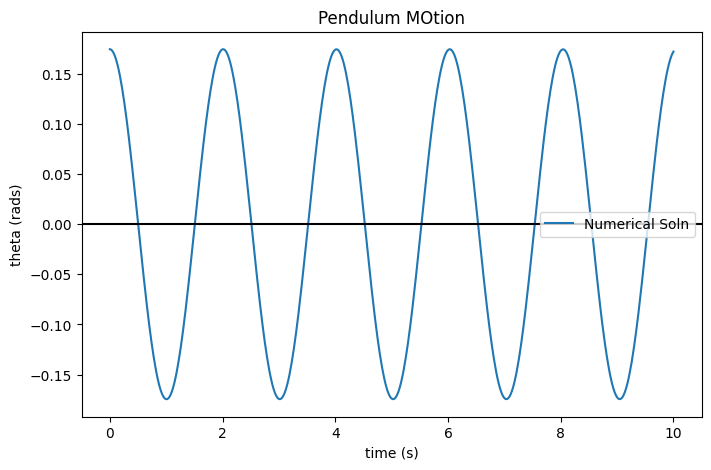

In [12]:
# Your code here
plt.figure(figsize=(8,5))
plt.plot(time_values, theta_values, label="Numerical Soln")
plt.axhline(0, color='black')
plt.xlabel("time (s)")
plt.ylabel("theta (rads)")
plt.title("Pendulum MOtion")
plt.legend()
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [13]:
# Your code here
print(f"Numerical period: {T_numerical:.4g} seconds")

Numerical period: 2.004 seconds


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [14]:
# Your comment here
percentage_error = abs((T_numerical - theoretical_period)/ theoretical_period) * 100
print(f"Percent diff: {percentage_error:.2f} %")

Percent diff: 0.15 %


## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [15]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [16]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [17]:
# Your code here
df=pd.read_csv(url)

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [18]:
# Your code here
df_country=df[df["location"]=="United States"]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [19]:
# Your code here
df_country = df_country[["date", "total_cases"]].dropna()
df_country["days since start"]=range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [20]:
# Your code here
df_country.head()

,date,total_cases,days since start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [21]:
# Your code here
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [23]:
# Your code here
def exponential_growth(t, C_0, r):
    return C_0* np.exp(r*t)

In [24]:
# Your code here
days = df_country["days since start"].iloc[:30]
cases = df_country["total_cases"].iloc[:30]

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [25]:
# Your code here
popt, pcov = curve_fit(exponential_growth, days, cases, p0 = [1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [26]:
# Your code here
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [27]:
# Your code here
print(f"C0: {C0_fit:.2g}")
print(f"r: {r_fit:.4g}")

C0: 0.12
r: 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [28]:
# Your code here
future_days = np.arange(0, 61)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [29]:
# Your code here 
predicted_cases = exponential_growth(future_days, *popt)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

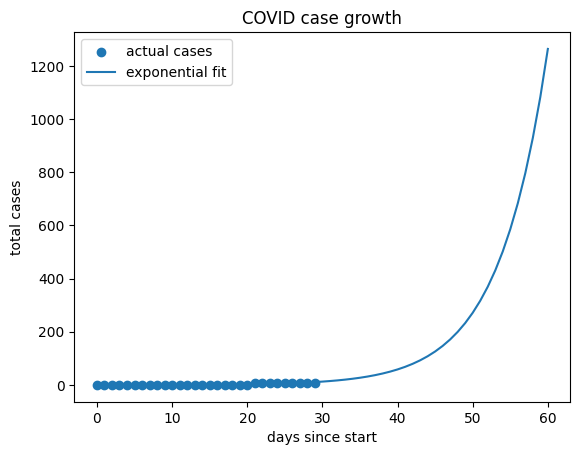

In [31]:
# Your code here
plt.scatter(days, cases, label="actual cases")
plt.plot(future_days, predicted_cases, label="exponential fit")
plt.xlabel("days since start")
plt.ylabel("total cases")
plt.title("COVID case growth")
plt.legend()
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [34]:
# Your comment here
y_actual = cases
y_predicted = exponential_growth(days, *popt)
y_mean = np.mean(y_actual)
ss_total = np.sum((y_actual - y_mean) **2)
ss_residual = np.sum((y_actual - y_predicted) **2)
r_squared = 1- (ss_residual/ss_total)
print(f"r^2: {r_squared:.4f}")
#r^2 is pretty close to 1 but definitely has some error

r^2: 0.8022


Make another plot but this time to **90 days**.

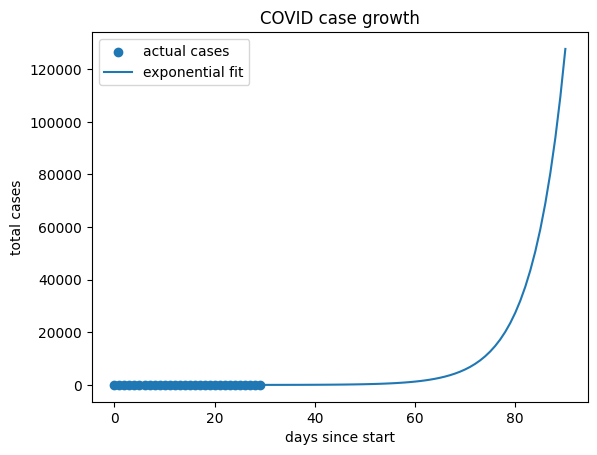

In [35]:
# Your code here
more_future_days = np.arange(1,91)
predicted_cases_more = exponential_growth(more_future_days, *popt)
plt.scatter(days, cases, label="actual cases")
plt.plot(more_future_days, predicted_cases_more, label="exponential fit")
plt.xlabel("days since start")
plt.ylabel("total cases")
plt.title("COVID case growth")
plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [39]:
# Your code here
predicted_cases_87 = exponential_growth(87, *popt)
print(f"predicted cases day 87: {predicted_cases_87:.0f}")

predicted cases day 87: 80497


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

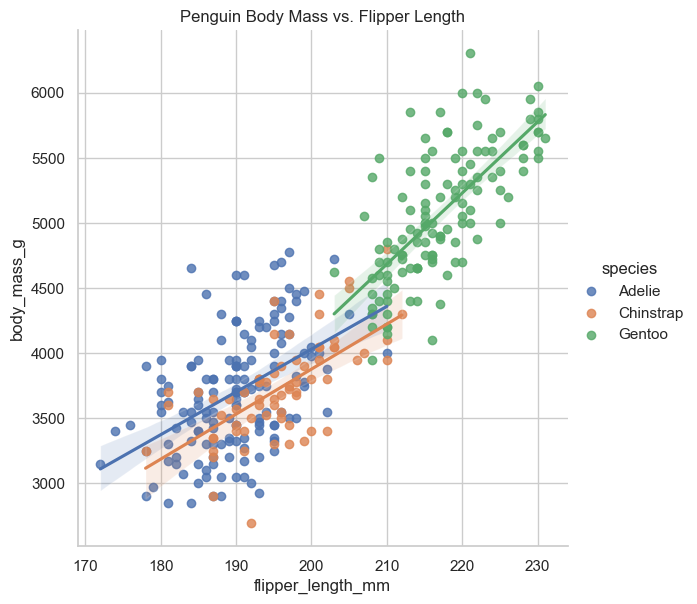

In [41]:
# Your code here
import seaborn as sns
import scipy.stats as stats

penguins = sns.load_dataset('penguins')

#seaborn scatter plot with regression line
sns.set(style="whitegrid")
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=penguins, hue="species", height=6)
plt.title("Penguin Body Mass vs. Flipper Length")
plt.show()


In [ ]:
#clear rows with missing values
penguins_clean = penguins.dropna(subset=['flipper_length_mm', 'body_mass_g'])

#extract columns
x = penguins_clean['flipper_length_mm']
y = penguins_clean['body_mass_g']

#scipy linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Print the results of the regression
print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}, R-squared: {r_value**2:.2f}")

# Plot the data with the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data points", alpha=0.7)
plt.plot(x, slope*x + intercept, color="red", label="Fitted line", lw=2)
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Linear Regression Model: Body Mass vs. Flipper Length")
plt.legend()
plt.show()


On it's own branch, submit this notebook to Gradescope! 